# Phase 2: Traditional ML Action Prediction

## Objective
Train a robust Machine Learning model to predict standard **Support Actions** based on the content of a support ticket. This notebook focuses on the classification layer of our Hybrid Support Intelligence System.

## Rationale for IEEE Paper
- **Static Classification**: Traditional ML provides sub-50ms inference, making it ideal for the first stage of ticket routing.
- **Action Standardization**: Mapping diverse ticket types to executable corporate actions.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import os

print("Libraries loaded. Preparing training pipeline...")

Libraries loaded. Preparing training pipeline...


## 1. Data Ingestion & Label Engineering
We use the `customer_support_tickets.csv` dataset and map the `Ticket Type` to actionable categories.

In [3]:
# Path to raw data
data_path = '../data/raw/customer_support_tickets.csv'

try:
    df = pd.read_csv(data_path)
    
    # Standardized Action Mapping
    action_map = {
        'Technical issue': 'Initiate Troubleshooting',
        'Billing inquiry': 'Review & Explain Charges',
        'Cancellation request': 'Process Cancellation',
        'Product inquiry': 'Provide Product Specs',
        'Refund request': 'Issue Refund'
    }

    df['Action_Label'] = df['Ticket Type'].map(action_map)
    
    # Preprocessing: Combine Subject and Description for richer context
    df['text_content'] = (df['Ticket Subject'].fillna('') + " " + df['Ticket Description'].fillna('')).str.lower()
    
    # Focus on non-null clean records
    clean_df = df.dropna(subset=['Action_Label', 'text_content']).copy()
    
    print(f"Dataset Processed. Total Samples: {len(clean_df)}")
    print("\nClass Distribution squashed to 5 actions:")
    print(clean_df['Action_Label'].value_counts())

except Exception as e:
    print(f"Error loading data: {e}")

Dataset Processed. Total Samples: 8469

Class Distribution squashed to 5 actions:
Action_Label
Issue Refund                1752
Initiate Troubleshooting    1747
Process Cancellation        1695
Provide Product Specs       1641
Review & Explain Charges    1634
Name: count, dtype: int64


## 2. Advanced Training Pipeline
We use an N-gram enabled TF-IDF vectorizer and a Random Forest Classifier for robust feature importance capture.

In [4]:
# Split Data
X = clean_df['text_content']
y = clean_df['Action_Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define Pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=5000, 
        stop_words='english', 
        ngram_range=(1, 3), # Unigrams, Bigrams, and Trigrams
        use_idf=True
    )),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

print("Training the Random Forest model...")
pipeline.fit(X_train, y_train)

print("Model Training Complete!")

Training the Random Forest model...
Model Training Complete!


## 3. Detailed Performance Evaluation
Analyzing accuracy and confusion patterns.

Overall Accuracy: 0.2007

--- Detailed Classification Report ---
                          precision    recall  f1-score   support

Initiate Troubleshooting       0.19      0.22      0.20       349
            Issue Refund       0.19      0.19      0.19       351
    Process Cancellation       0.22      0.21      0.22       339
   Provide Product Specs       0.22      0.22      0.22       328
Review & Explain Charges       0.18      0.16      0.17       327

                accuracy                           0.20      1694
               macro avg       0.20      0.20      0.20      1694
            weighted avg       0.20      0.20      0.20      1694



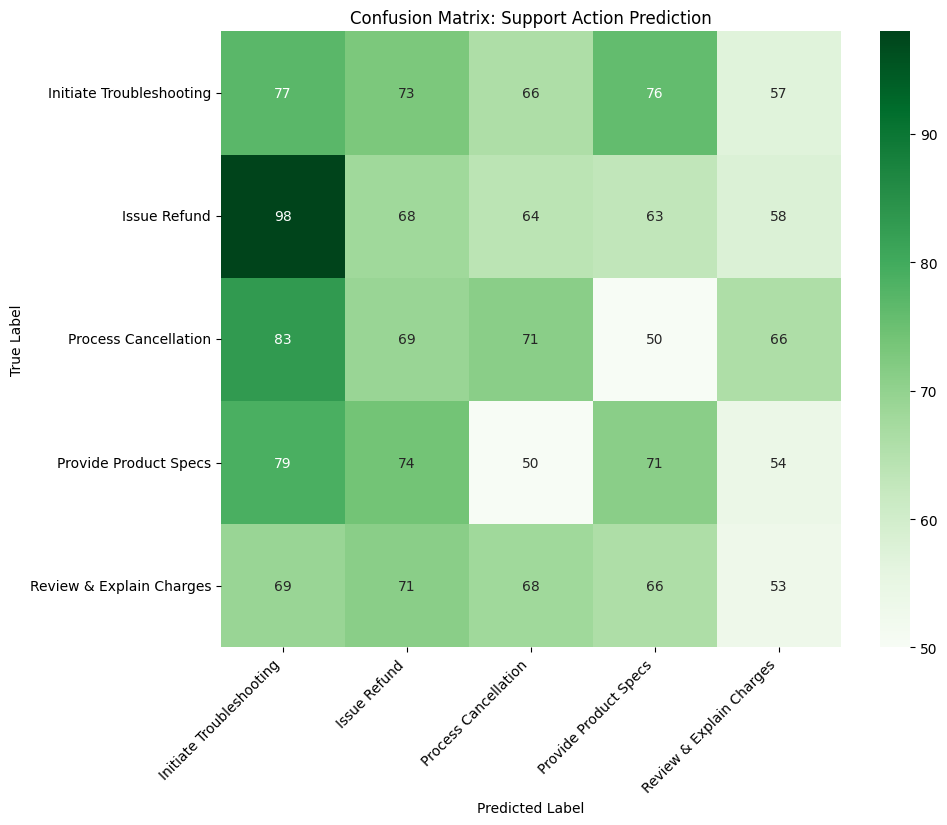

In [5]:
y_pred = pipeline.predict(X_test)

print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

# Visualize Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', 
            xticklabels=pipeline.classes_, 
            yticklabels=pipeline.classes_)
plt.title('Confusion Matrix: Support Action Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.show()

## 4. Inference Engine
A simple function to predict actions for new incoming tickets.

In [6]:
def predict_action(subject, description):
    combined = (subject + " " + description).lower()
    pred = pipeline.predict([combined])[0]
    probs = pipeline.predict_proba([combined])[0]
    conf = max(probs)
    return pred, conf

# Interactive Test
test_subject = "Login Error"
test_desc = "I cannot access my portal and the screen shows 403 error."

action, score = predict_action(test_subject, test_desc)
print(f"Ticket: {test_subject}")
print(f"Predicted Action: {action} (Confidence: {score:.2f})")

Ticket: Login Error
Predicted Action: Initiate Troubleshooting (Confidence: 0.29)


## 5. Persistence
Saving the model for use in the final hybrid system.

In [ ]:
import pickle

model_dir = '../models/'
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, 'action_predictor_rf.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(pipeline, f)

print(f"Model saved successfully to: {model_path}")